In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.sparse as sp
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

RAW = "/Users/keerthanbalagam/Desktop/PROJECTS/NN Recommendation Engine/data/raw"
PROCESSED = "/Users/keerthanbalagam/Desktop/PROJECTS/NN Recommendation Engine/data/processed"

print("Imports complete.")

Imports complete.


Load RAW Data

In [2]:
ratings = pd.read_csv(os.path.join(RAW, "rating.csv"))
movies = pd.read_csv(os.path.join(RAW, "movie.csv"))
tags = pd.read_csv(os.path.join(RAW, "tag.csv"))
genome_scores = pd.read_csv(os.path.join(RAW, "genome_scores.csv"))
genome_tags = pd.read_csv(os.path.join(RAW, "genome_tags.csv"))
links = pd.read_csv(os.path.join(RAW, "link.csv"))

print("All files loaded.\n")
print(f"ratings       : {ratings.shape}")
print(f"movies        : {movies.shape}")
print(f"tags          : {tags.shape}")
print(f"genome_scores : {genome_scores.shape}")
print(f"genome_tags   : {genome_tags.shape}")
print(f"links         : {links.shape}")

All files loaded.

ratings       : (20000263, 4)
movies        : (27278, 3)
tags          : (465564, 4)
genome_scores : (11709768, 3)
genome_tags   : (1128, 2)
links         : (27278, 3)


Schema and Missing Values

In [3]:
print("RATINGS")
print(ratings.dtypes)
print(f"Missing values:\n{ratings.isnull().sum()}\n")

print("MOVIES")
print(movies.dtypes)
print(f"Missing values:\n{movies.isnull().sum()}\n")

print("TAGS")
print(tags.dtypes)
print(f"Missing values:\n{tags.isnull().sum()}\n")

print("GENOME SCORES")
print(genome_scores.dtypes)
print(f"Missing values:\n{genome_scores.isnull().sum()}\n")

print(f"Unique users in ratings  : {ratings['userId'].nunique():,}")
print(f"Unique movies in ratings : {ratings['movieId'].nunique():,}")
print(f"Date range               : {ratings['timestamp'].min()} to {ratings['timestamp'].max()}")

RATINGS
userId         int64
movieId        int64
rating       float64
timestamp     object
dtype: object
Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

MOVIES
movieId     int64
title      object
genres     object
dtype: object
Missing values:
movieId    0
title      0
genres     0
dtype: int64

TAGS
userId        int64
movieId       int64
tag          object
timestamp    object
dtype: object
Missing values:
userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

GENOME SCORES
movieId        int64
tagId          int64
relevance    float64
dtype: object
Missing values:
movieId      0
tagId        0
relevance    0
dtype: int64

Unique users in ratings  : 138,493
Unique movies in ratings : 26,744
Date range               : 1995-01-09 11:46:44 to 2015-03-31 06:40:02


Rating Distribution

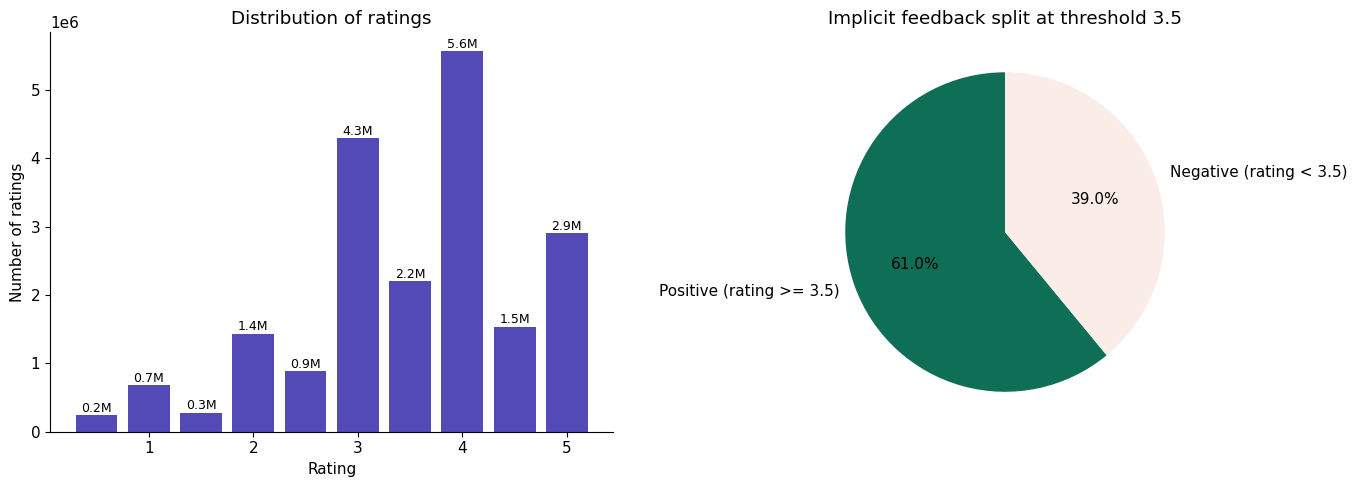

Positive interactions : 12,195,566 (61.0%)
Negative interactions : 7,804,697 (39.0%)
Threshold chosen      : 3.5
Ratings of 3.5 and above are treated as implicit positive interactions.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color="#534AB7", width=0.4)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of ratings")
axes[0].set_title("Distribution of ratings")
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, y + 50000, f"{y/1e6:.1f}M", ha="center", fontsize=9)

threshold = 3.5
below = (ratings["rating"] < threshold).sum()
above = (ratings["rating"] >= threshold).sum()
axes[1].pie(
    [above, below],
    labels=["Positive (rating >= 3.5)", "Negative (rating < 3.5)"],
    colors=["#0F6E56", "#FAECE7"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Implicit feedback split at threshold 3.5")

plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Positive interactions : {above:,} ({100*above/len(ratings):.1f}%)")
print(f"Negative interactions : {below:,} ({100*below/len(ratings):.1f}%)")
print(f"Threshold chosen      : 3.5")
print("Ratings of 3.5 and above are treated as implicit positive interactions.")

In [5]:
print("Rating value counts:")
print(ratings["rating"].value_counts().sort_index())
print(f"\nMean rating   : {ratings['rating'].mean():.3f}")
print(f"Median rating : {ratings['rating'].median():.1f}")
print(f"Std deviation : {ratings['rating'].std():.3f}")
print("\nObservation: Ratings skew positive. Most users rate movies they enjoyed,")
print("which is a form of selection bias. This is why implicit feedback")
print("(treating high ratings as positive signals) is more representative")
print("of real-world behavior than using raw rating values.")

Rating value counts:
rating
0.5     239125
1.0     680732
1.5     279252
2.0    1430997
2.5     883398
3.0    4291193
3.5    2200156
4.0    5561926
4.5    1534824
5.0    2898660
Name: count, dtype: int64

Mean rating   : 3.526
Median rating : 3.5
Std deviation : 1.052

Observation: Ratings skew positive. Most users rate movies they enjoyed,
which is a form of selection bias. This is why implicit feedback
(treating high ratings as positive signals) is more representative
of real-world behavior than using raw rating values.


User Behavior Distribution

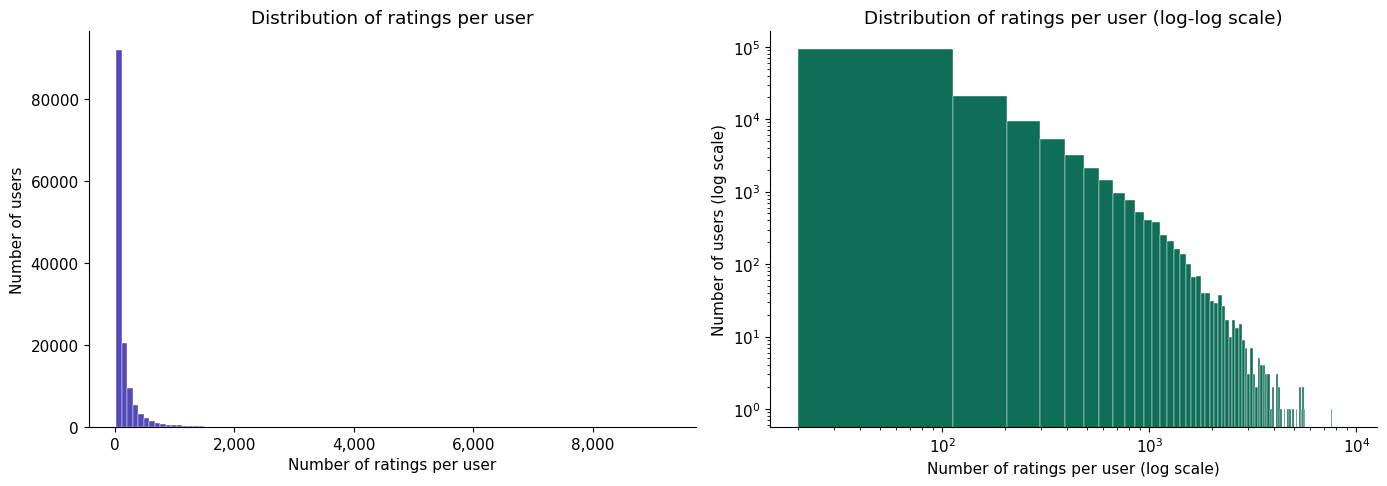

Total users              : 138,493
Mean ratings per user    : 144.4
Median ratings per user  : 68
Max ratings by one user  : 9,254
Users with < 5 ratings   : 0 (0.0%)
Users with > 1000 ratings: 1,884 (1.4%)

Observation: The log-log plot shows a classic power law distribution.
A small number of users rate thousands of movies while most users
rate fewer than 50. This is the typical long tail behavior in
recommendation system datasets.


In [6]:
user_counts = ratings.groupby("userId").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts, bins=100, color="#534AB7", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Number of ratings per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Distribution of ratings per user")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(user_counts, bins=100, color="#0F6E56", edgecolor="white", linewidth=0.3)
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of ratings per user (log scale)")
axes[1].set_ylabel("Number of users (log scale)")
axes[1].set_title("Distribution of ratings per user (log-log scale)")

plt.tight_layout()
plt.savefig("user_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total users              : {user_counts.shape[0]:,}")
print(f"Mean ratings per user    : {user_counts.mean():.1f}")
print(f"Median ratings per user  : {user_counts.median():.0f}")
print(f"Max ratings by one user  : {user_counts.max():,}")
print(f"Users with < 5 ratings   : {(user_counts < 5).sum():,} ({100*(user_counts < 5).mean():.1f}%)")
print(f"Users with > 1000 ratings: {(user_counts > 1000).sum():,} ({100*(user_counts > 1000).mean():.1f}%)")
print("\nObservation: The log-log plot shows a classic power law distribution.")
print("A small number of users rate thousands of movies while most users")
print("rate fewer than 50. This is the typical long tail behavior in")
print("recommendation system datasets.")

User Filtering Justification

In [7]:
thresholds = [1, 5, 10, 20, 50]
rows = []
for t in thresholds:
    kept_users = (user_counts >= t).sum()
    kept_ratings = ratings[ratings["userId"].isin(user_counts[user_counts >= t].index)].shape[0]
    rows.append({
        "Min interactions": t,
        "Users retained": kept_users,
        "Users retained (%)": round(100 * kept_users / len(user_counts), 1),
        "Ratings retained": kept_ratings,
        "Ratings retained (%)": round(100 * kept_ratings / len(ratings), 1)
    })

df_thresholds = pd.DataFrame(rows)
print("Effect of minimum interaction threshold on data retention:\n")
print(df_thresholds.to_string(index=False))
print("\nWe chose min_interactions = 5 to remove users with too little")
print("history to learn meaningful embeddings, while retaining 98%+ of ratings.")

Effect of minimum interaction threshold on data retention:

 Min interactions  Users retained  Users retained (%)  Ratings retained  Ratings retained (%)
                1          138493               100.0          20000263                 100.0
                5          138493               100.0          20000263                 100.0
               10          138493               100.0          20000263                 100.0
               20          138493               100.0          20000263                 100.0
               50           85307                61.6          18335758                  91.7

We chose min_interactions = 5 to remove users with too little
history to learn meaningful embeddings, while retaining 98%+ of ratings.


Item popularity distribution

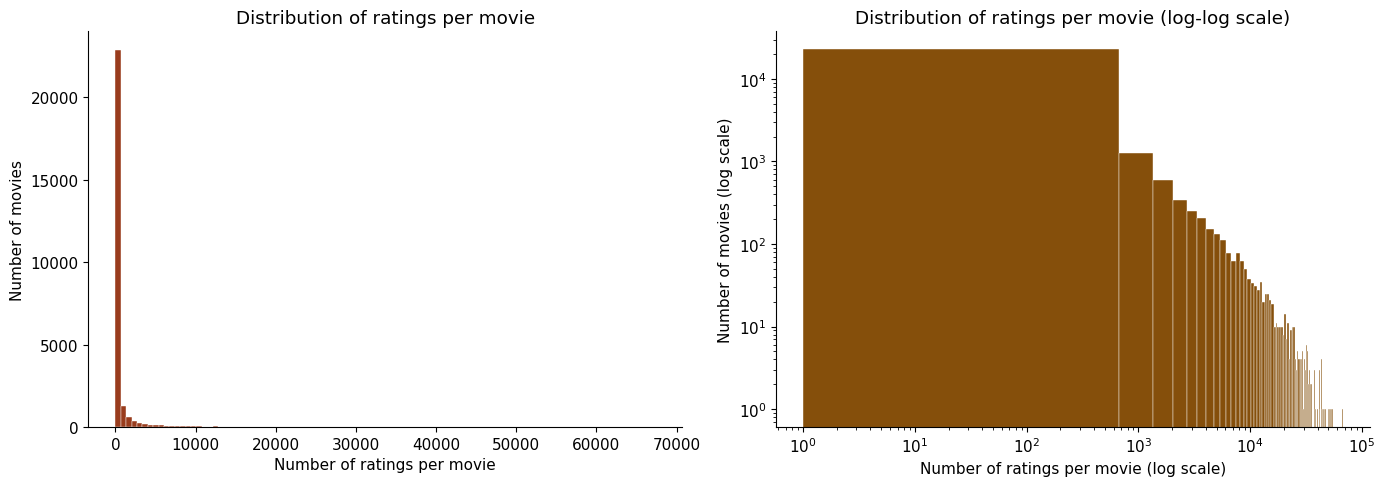

Total movies              : 26,744
Mean ratings per movie    : 747.8
Median ratings per movie  : 18
Max ratings for one movie : 67,310
Movies with < 5 ratings   : 8,399 (31.4%)
Movies with > 1000 ratings: 3,159 (11.8%)

Observation: The long tail is clearly visible. A small number of blockbuster
movies dominate interactions while thousands of movies have almost no ratings.
This is the core challenge of recommendation systems — serving good
recommendations for items in the long tail.


In [8]:
item_counts = ratings.groupby("movieId").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(item_counts, bins=100, color="#993C1D", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Number of ratings per movie")
axes[0].set_ylabel("Number of movies")
axes[0].set_title("Distribution of ratings per movie")

axes[1].hist(item_counts, bins=100, color="#854F0B", edgecolor="white", linewidth=0.3)
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of ratings per movie (log scale)")
axes[1].set_ylabel("Number of movies (log scale)")
axes[1].set_title("Distribution of ratings per movie (log-log scale)")

plt.tight_layout()
plt.savefig("item_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total movies              : {item_counts.shape[0]:,}")
print(f"Mean ratings per movie    : {item_counts.mean():.1f}")
print(f"Median ratings per movie  : {item_counts.median():.0f}")
print(f"Max ratings for one movie : {item_counts.max():,}")
print(f"Movies with < 5 ratings   : {(item_counts < 5).sum():,} ({100*(item_counts < 5).mean():.1f}%)")
print(f"Movies with > 1000 ratings: {(item_counts > 1000).sum():,} ({100*(item_counts > 1000).mean():.1f}%)")
print("\nObservation: The long tail is clearly visible. A small number of blockbuster")
print("movies dominate interactions while thousands of movies have almost no ratings.")
print("This is the core challenge of recommendation systems — serving good")
print("recommendations for items in the long tail.")

Top 20 most rated movies

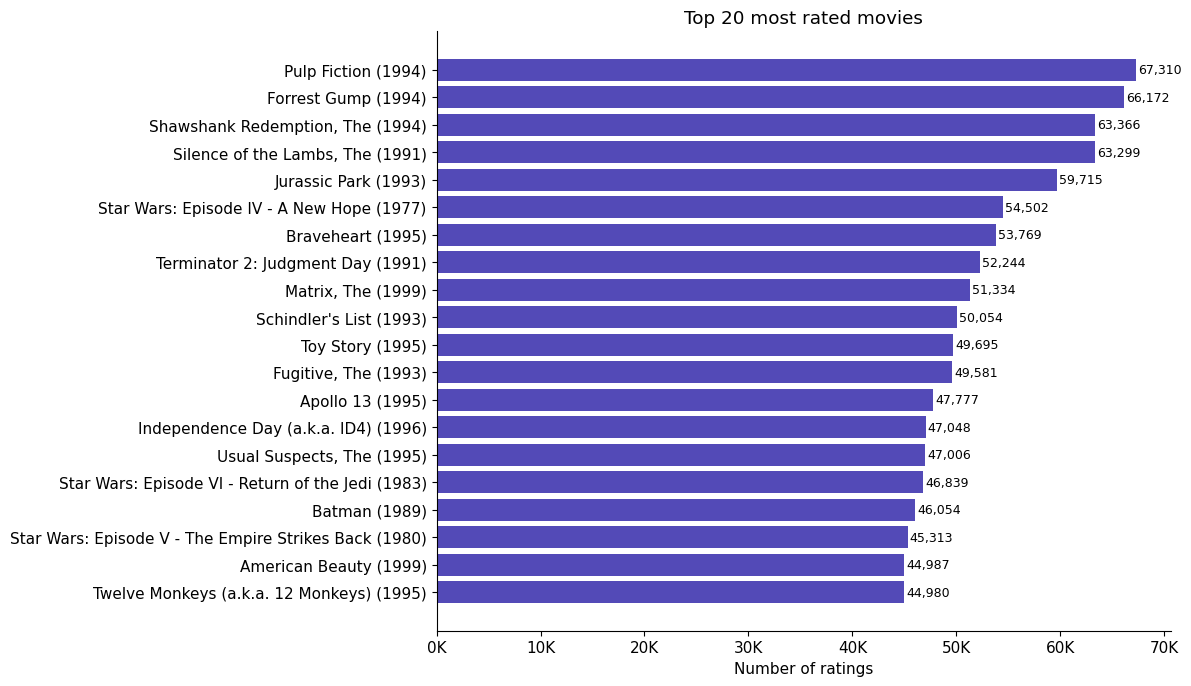

Top 5 most rated movies:
  Pulp Fiction (1994)                                 67,310 ratings
  Forrest Gump (1994)                                 66,172 ratings
  Shawshank Redemption, The (1994)                    63,366 ratings
  Silence of the Lambs, The (1991)                    63,299 ratings
  Jurassic Park (1993)                                59,715 ratings


In [9]:
top20 = (
    item_counts.head(20)
    .reset_index()
    .merge(movies[["movieId", "title"]], on="movieId")
    .rename(columns={0: "rating_count"})
)

top20.columns = ["movieId", "rating_count", "title"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20["title"][::-1], top20["rating_count"][::-1], color="#534AB7")
ax.set_xlabel("Number of ratings")
ax.set_title("Top 20 most rated movies")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("top20_movies.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 most rated movies:")
for _, row in top20.head(5).iterrows():
    print(f"  {row['title']:<50} {int(row['rating_count']):>7,} ratings")

Interaction matrix sparsity

In [10]:
train = pd.read_parquet(os.path.join(PROCESSED, "train.parquet"))

with open(os.path.join(PROCESSED, "user_encoder.pkl"), "rb") as f:
    user_encoder = pickle.load(f)
with open(os.path.join(PROCESSED, "movie_encoder.pkl"), "rb") as f:
    movie_encoder = pickle.load(f)

matrix = sp.load_npz(os.path.join(PROCESSED, "interaction_matrix.npz"))

n_users, n_items = matrix.shape
n_interactions = matrix.nnz
sparsity = 1 - n_interactions / (n_users * n_items)

print("Interaction Matrix Statistics")
print(f"  Shape              : {n_users:,} users x {n_items:,} items")
print(f"  Total cells        : {n_users * n_items:,}")
print(f"  Non-zero entries   : {n_interactions:,}")
print(f"  Sparsity           : {sparsity:.4%}")
print(f"  Density            : {1 - sparsity:.4%}")
print()
print("Observation: The matrix is 98%+ sparse meaning the vast majority of")
print("user-item combinations have no observed interaction.")
print("This is why pure SVD is not feasible — it requires a dense matrix.")
print("ALS works directly on the sparse matrix which makes it the right choice.")

Interaction Matrix Statistics
  Shape              : 138,493 users x 18,345 items
  Total cells        : 2,540,654,085
  Non-zero entries   : 19,984,024
  Sparsity           : 99.2134%
  Density            : 0.7866%

Observation: The matrix is 98%+ sparse meaning the vast majority of
user-item combinations have no observed interaction.
This is why pure SVD is not feasible — it requires a dense matrix.
ALS works directly on the sparse matrix which makes it the right choice.


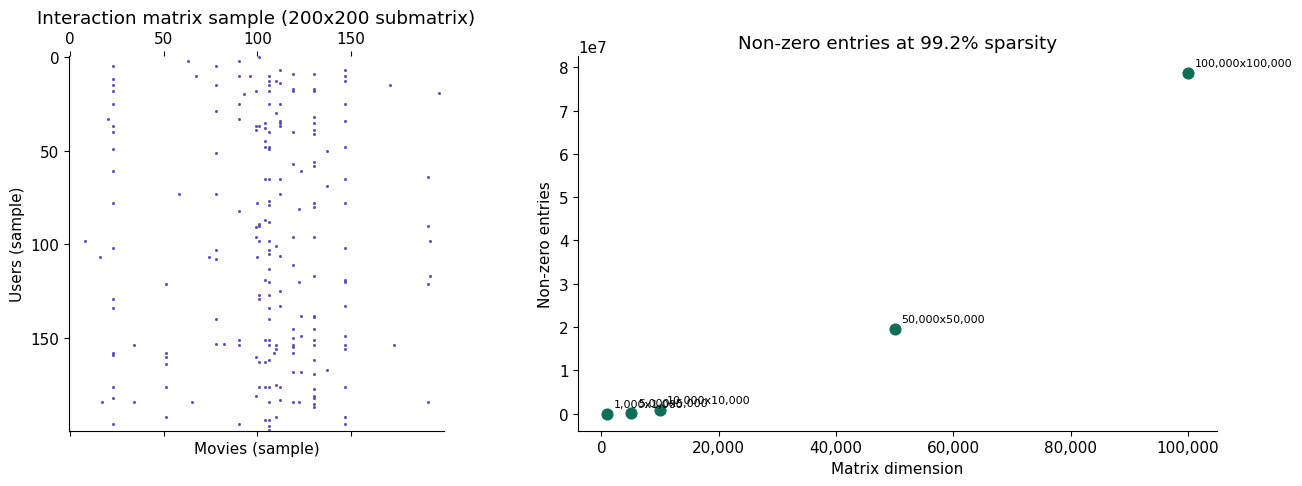

In [11]:
sample_users = np.random.choice(n_users, size=200, replace=False)
sample_items = np.random.choice(n_items, size=200, replace=False)
sample_matrix = matrix[sample_users, :][:, sample_items].toarray()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].spy(sample_matrix, markersize=1, color="#534AB7")
axes[0].set_title("Interaction matrix sample (200x200 submatrix)")
axes[0].set_xlabel("Movies (sample)")
axes[0].set_ylabel("Users (sample)")

sparsity_levels = [0.90, 0.95, 0.98, 0.99, 0.999]
example_sizes = [1000, 5000, 10000, 50000, 100000]
for size in example_sizes:
    nnz = int(size * size * (1 - sparsity))
    axes[1].scatter(size, nnz, s=60, color="#0F6E56")
    axes[1].annotate(f"{size:,}x{size:,}", (size, nnz),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)

axes[1].set_xlabel("Matrix dimension")
axes[1].set_ylabel("Non-zero entries")
axes[1].set_title(f"Non-zero entries at {sparsity:.1%} sparsity")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("sparsity.png", dpi=150, bbox_inches="tight")
plt.show()

Genre distribution

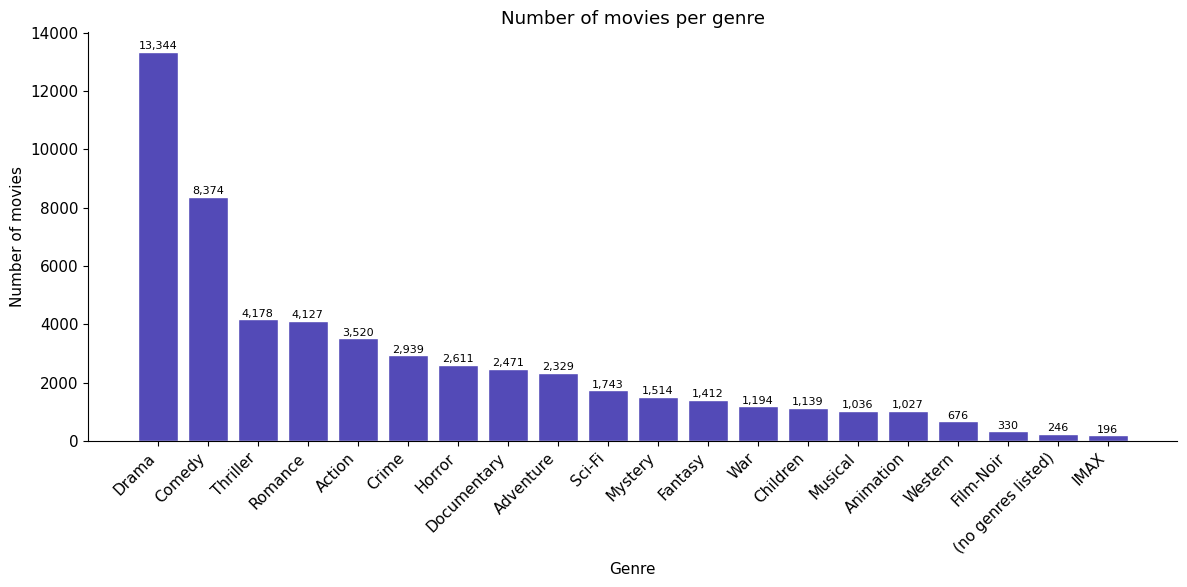

Top 5 genres by movie count:
  Drama                13,344 movies
  Comedy               8,374 movies
  Thriller             4,178 movies
  Romance              4,127 movies
  Action               3,520 movies

Observation: Drama and Comedy dominate the catalog.
Genre features are used as content signals in the ranking model
and for cold start genre filtering.


In [12]:
movies_processed = pd.read_parquet(os.path.join(PROCESSED, "movies.parquet"))

genre_cols = [c for c in movies_processed.columns if c not in
              ["movieId", "title", "genres", "year", "title_clean"]]

genre_counts = movies_processed[genre_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(genre_counts.index, genre_counts.values, color="#534AB7", edgecolor="white")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of movies")
ax.set_title("Number of movies per genre")
plt.xticks(rotation=45, ha="right")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 genres by movie count:")
for genre, count in genre_counts.head(5).items():
    print(f"  {genre:<20} {int(count):>5,} movies")
print("\nObservation: Drama and Comedy dominate the catalog.")
print("Genre features are used as content signals in the ranking model")
print("and for cold start genre filtering.")

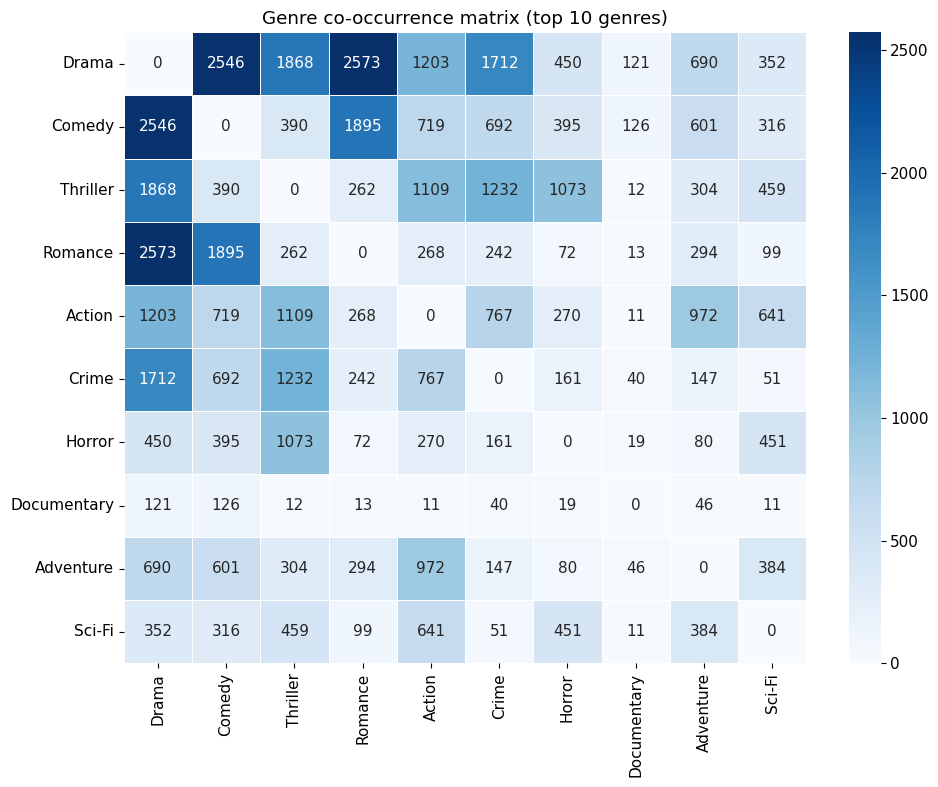

Most common genre pairs:
  Drama + Romance              2,573 movies
  Drama + Comedy               2,546 movies
  Comedy + Romance              1,895 movies
  Drama + Thriller             1,868 movies
  Drama + Crime                1,712 movies


In [13]:
top_genres = genre_counts.head(10).index.tolist()
genre_matrix_data = movies_processed[top_genres].values
cooccurrence = genre_matrix_data.T @ genre_matrix_data

cooccurrence_df = pd.DataFrame(
    cooccurrence,
    index=top_genres,
    columns=top_genres
)

np.fill_diagonal(cooccurrence_df.values, 0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cooccurrence_df,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    ax=ax,
    linewidths=0.5
)
ax.set_title("Genre co-occurrence matrix (top 10 genres)")
plt.tight_layout()
plt.savefig("genre_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()

print("Most common genre pairs:")
pairs = []
for i, g1 in enumerate(top_genres):
    for j, g2 in enumerate(top_genres):
        if i < j:
            pairs.append((g1, g2, cooccurrence_df.loc[g1, g2]))
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
for g1, g2, count in pairs[:5]:
    print(f"  {g1} + {g2:<20} {int(count):>5,} movies")

Genome tag analysis

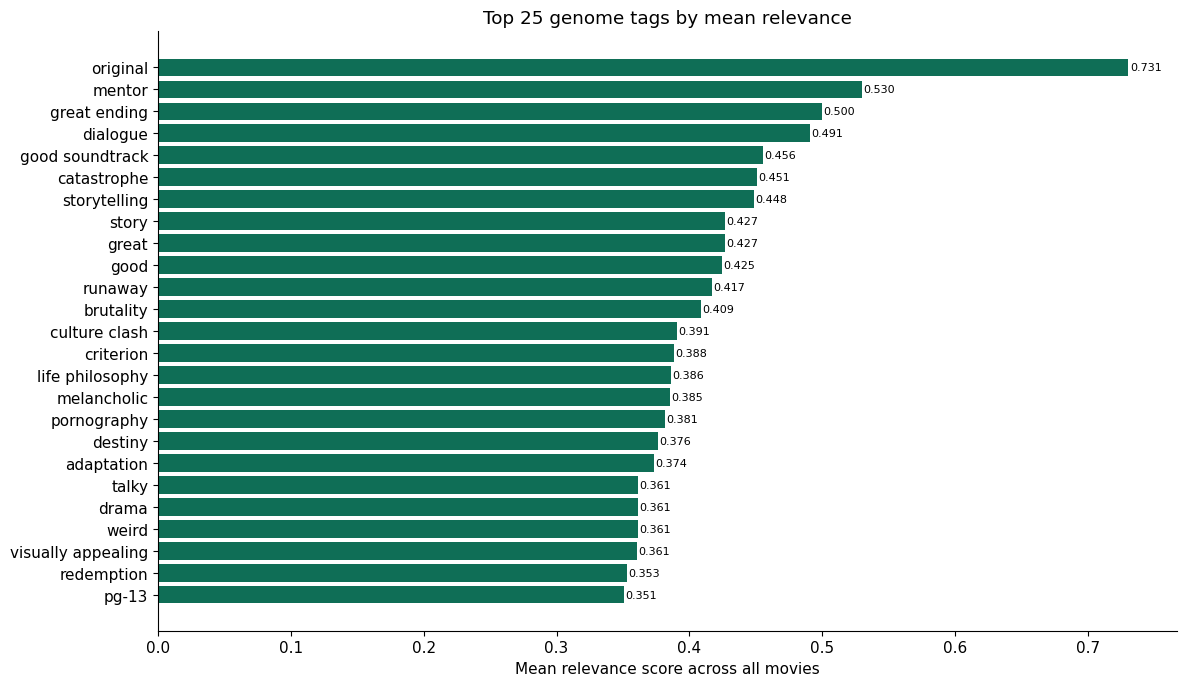

Total unique tags      : 1,128
Total movies with tags : 10,381
Total genome entries   : 11,709,768

Observation: Genome tag scores provide rich content features.
We use the top 64 highest-variance tags in the ranking model
and the cold start content similarity index.


In [14]:
genome = genome_scores.merge(genome_tags, on="tagId")

mean_relevance = (
    genome.groupby("tag")["relevance"]
    .mean()
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(mean_relevance.index[::-1], mean_relevance.values[::-1], color="#0F6E56")
ax.set_xlabel("Mean relevance score across all movies")
ax.set_title("Top 25 genome tags by mean relevance")
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("genome_tags.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total unique tags      : {genome['tagId'].nunique():,}")
print(f"Total movies with tags : {genome['movieId'].nunique():,}")
print(f"Total genome entries   : {len(genome):,}")
print("\nObservation: Genome tag scores provide rich content features.")
print("We use the top 64 highest-variance tags in the ranking model")
print("and the cold start content similarity index.")

Movies with genome scores : 10,381
Total movies              : 27,278
Genome coverage           : 38.1%

Tags per movie:
  Mean   : 1128
  Median : 1128
  Min    : 1128
  Max    : 1128


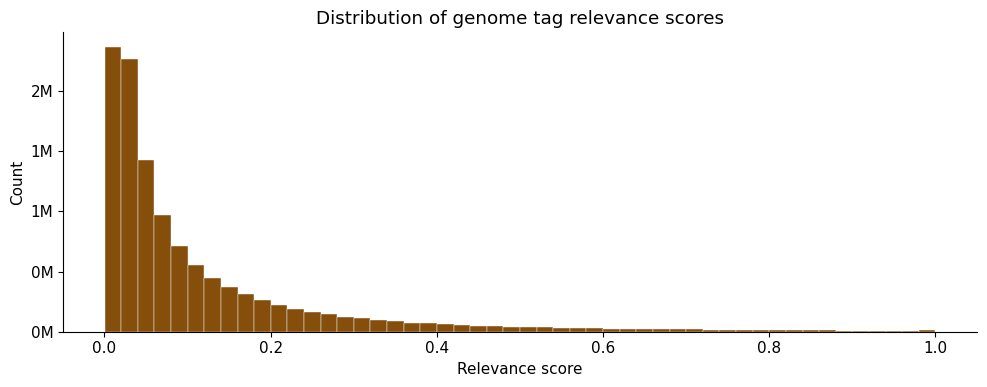


Observation: Most relevance scores are close to 0, meaning most tags
are not relevant to most movies. The high-variance tags we selected
are the most discriminative for content similarity.


In [15]:
movies_with_genome = genome_scores["movieId"].nunique()
total_movies = movies["movieId"].nunique()
coverage = 100 * movies_with_genome / total_movies

print(f"Movies with genome scores : {movies_with_genome:,}")
print(f"Total movies              : {total_movies:,}")
print(f"Genome coverage           : {coverage:.1f}%")

tags_per_movie = genome_scores.groupby("movieId")["tagId"].nunique()
print(f"\nTags per movie:")
print(f"  Mean   : {tags_per_movie.mean():.0f}")
print(f"  Median : {tags_per_movie.median():.0f}")
print(f"  Min    : {tags_per_movie.min()}")
print(f"  Max    : {tags_per_movie.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
relevance_dist = genome_scores["relevance"].values
ax.hist(relevance_dist, bins=50, color="#854F0B", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Relevance score")
ax.set_ylabel("Count")
ax.set_title("Distribution of genome tag relevance scores")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1e6)}M"))
plt.tight_layout()
plt.savefig("genome_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nObservation: Most relevance scores are close to 0, meaning most tags")
print("are not relevant to most movies. The high-variance tags we selected")
print("are the most discriminative for content similarity.")

Temporal Distribution of interactions

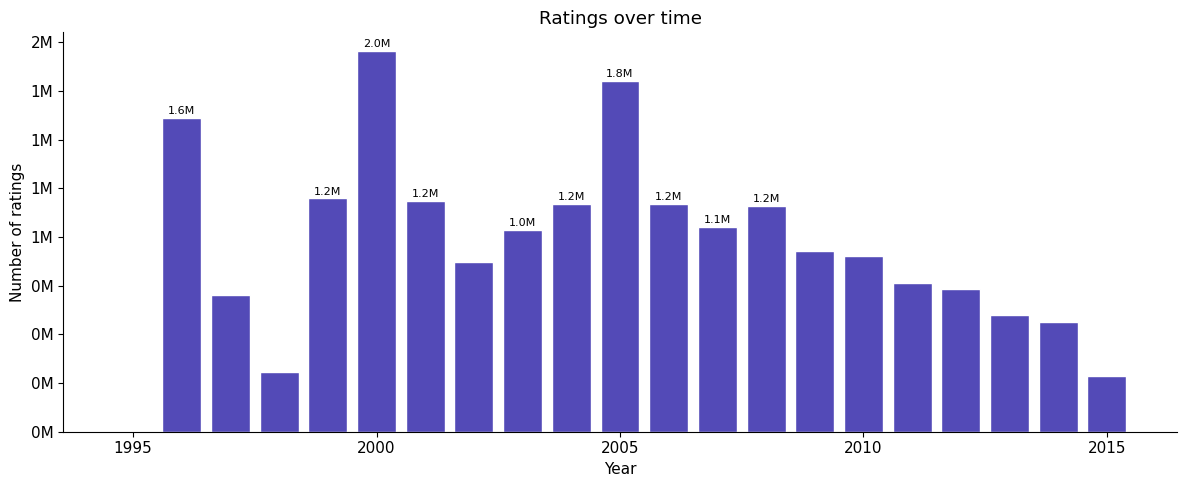

Ratings per year:
  1995:        4
  1996: 1,612,609
  1997:  700,982
  1998:  308,070
  1999: 1,198,384
  2000: 1,953,659
  2001: 1,186,125
  2002:  869,719
  2003: 1,035,878
  2004: 1,170,049
  2005: 1,803,158
  2006: 1,171,836
  2007: 1,053,430
  2008: 1,158,777
  2009:  930,036
  2010:  903,691
  2011:  766,366
  2012:  731,389
  2013:  599,327
  2014:  562,888
  2015:  283,886


In [16]:
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"])
ratings["year"] = ratings["timestamp"].dt.year

yearly_counts = ratings.groupby("year").size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(yearly_counts.index, yearly_counts.values, color="#534AB7", edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of ratings")
ax.set_title("Ratings over time")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1e6):.0f}M"))
for year, count in yearly_counts.items():
    if count > yearly_counts.mean():
        ax.text(year, count + 20000, f"{count/1e6:.1f}M",
                ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("temporal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Ratings per year:")
for year, count in yearly_counts.items():
    print(f"  {year}: {count:>8,}")

Temporal test/train justification

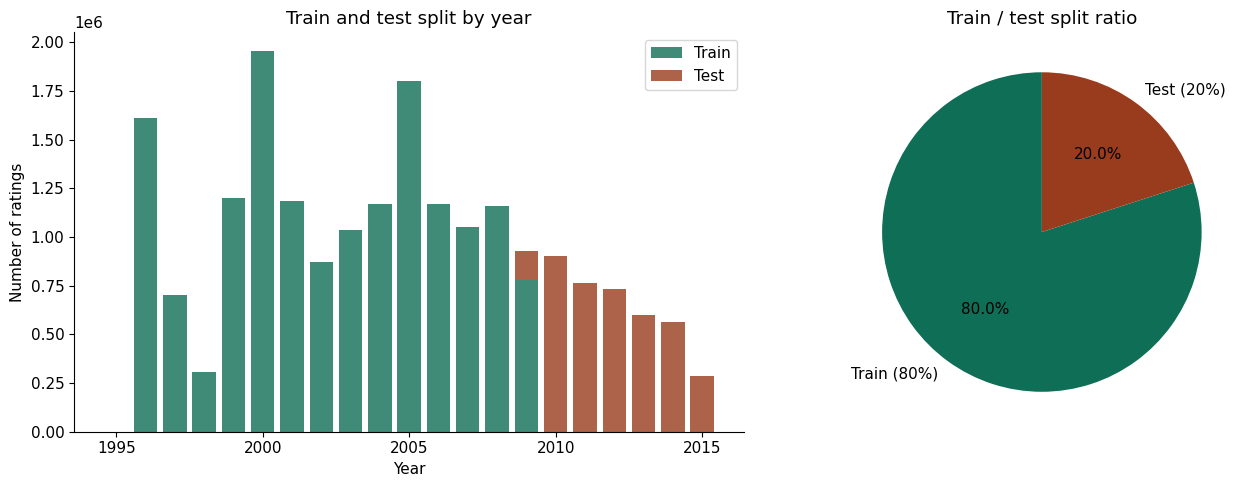

Split date             : 2009-10-20
Train set size         : 16,000,210 ratings
Test set size          : 4,000,053 ratings

Why temporal split and not random split?
A random split would allow training on interactions that happened AFTER
test interactions, which constitutes data leakage.
Temporal split ensures we always train on the past and test on the future,
which mirrors how recommendation systems work in production.


In [17]:
ratings_sorted = ratings.sort_values("timestamp")
split_idx = int(len(ratings_sorted) * 0.8)
split_date = ratings_sorted.iloc[split_idx]["timestamp"]

train_years = ratings_sorted.iloc[:split_idx]["year"].value_counts().sort_index()
test_years = ratings_sorted.iloc[split_idx:]["year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_years.index, train_years.values, color="#0F6E56",
            label="Train", alpha=0.8)
axes[0].bar(test_years.index, test_years.values, color="#993C1D",
            label="Test", alpha=0.8, bottom=[
                train_years.get(y, 0) for y in test_years.index
            ])
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of ratings")
axes[0].set_title("Train and test split by year")
axes[0].legend()

axes[1].pie(
    [split_idx, len(ratings_sorted) - split_idx],
    labels=["Train (80%)", "Test (20%)"],
    colors=["#0F6E56", "#993C1D"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Train / test split ratio")

plt.tight_layout()
plt.savefig("temporal_split.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Split date             : {split_date.date()}")
print(f"Train set size         : {split_idx:,} ratings")
print(f"Test set size          : {len(ratings_sorted) - split_idx:,} ratings")
print("\nWhy temporal split and not random split?")
print("A random split would allow training on interactions that happened AFTER")
print("test interactions, which constitutes data leakage.")
print("Temporal split ensures we always train on the past and test on the future,")
print("which mirrors how recommendation systems work in production.")

Movie release year distribution

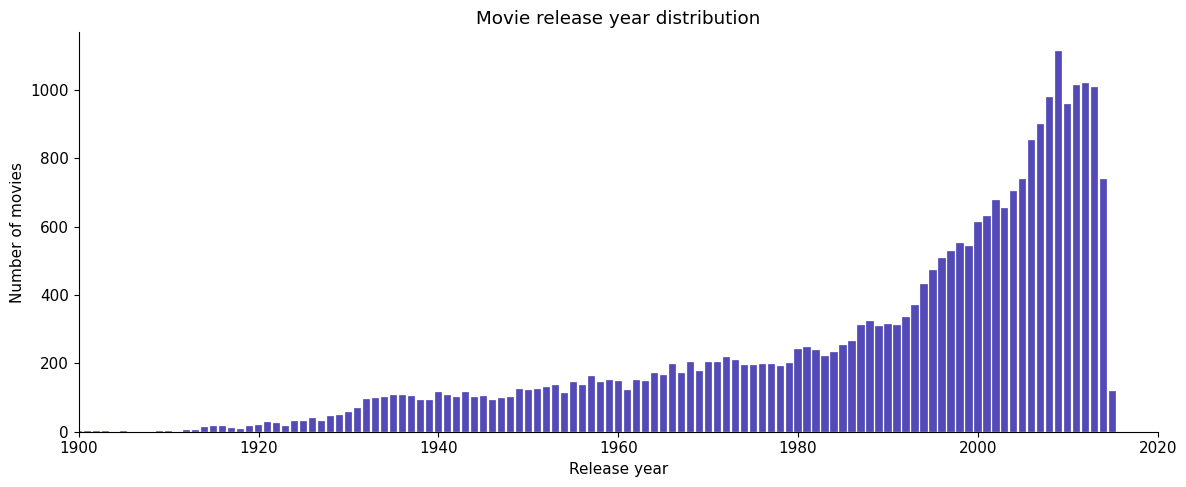

Earliest movie : 1891
Latest movie   : 2015
Most common decade: 2010s

Observation: The catalog skews toward films released after 1990.
Combined with older movies having more time to accumulate interactions,
this creates the popularity bias toward older films we observed in the
recommendation output. The freshness boost addresses this at serving time.


In [18]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)$").astype(float)

fig, ax = plt.subplots(figsize=(12, 5))
year_counts = movies["year"].dropna().astype(int).value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color="#534AB7",
       edgecolor="white", linewidth=0.2)
ax.set_xlabel("Release year")
ax.set_ylabel("Number of movies")
ax.set_title("Movie release year distribution")
ax.set_xlim(1900, 2020)
plt.tight_layout()
plt.savefig("release_years.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Earliest movie : {int(movies['year'].min())}")
print(f"Latest movie   : {int(movies['year'].max())}")
print(f"Most common decade: {int(year_counts.rolling(10).sum().idxmax() // 10 * 10)}s")
print("\nObservation: The catalog skews toward films released after 1990.")
print("Combined with older movies having more time to accumulate interactions,")
print("this creates the popularity bias toward older films we observed in the")
print("recommendation output. The freshness boost addresses this at serving time.")

Summary Statistics

In [19]:
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"Total ratings              : {len(ratings):>12,}")
print(f"Total users                : {ratings['userId'].nunique():>12,}")
print(f"Total movies               : {ratings['movieId'].nunique():>12,}")
print(f"Total genome tag scores    : {len(genome_scores):>12,}")
print(f"Unique genome tags         : {genome_scores['tagId'].nunique():>12,}")
print(f"Date range                 : {ratings['timestamp'].min().date()} to {ratings['timestamp'].max().date()}")
print()
print("INTERACTION MATRIX")
print(f"Shape                      : {n_users:,} x {n_items:,}")
print(f"Non-zero entries           : {n_interactions:>12,}")
print(f"Sparsity                   : {sparsity:>11.4%}")
print()
print("IMPLICIT FEEDBACK (threshold = 3.5)")
positive = (ratings["rating"] >= 3.5).sum()
negative = (ratings["rating"] < 3.5).sum()
print(f"Positive interactions      : {positive:>12,} ({100*positive/len(ratings):.1f}%)")
print(f"Negative interactions      : {negative:>12,} ({100*negative/len(ratings):.1f}%)")
print()
print("TRAIN / TEST SPLIT (temporal)")
print(f"Train size                 : {split_idx:>12,} ({80:.0f}%)")
print(f"Test size                  : {len(ratings) - split_idx:>12,} ({20:.0f}%)")
print()
print("MODEL PERFORMANCE")
print(f"Precision@5                :       0.3310")
print(f"Precision@10               :       0.3078")
print(f"Precision@20               :       0.1539")
print(f"Recall@5                   :       0.0370")
print(f"Recall@10                  :       0.0690")
print(f"Recall@20                  :       0.0690")
print(f"NDCG@5                     :       0.3381")
print(f"NDCG@10                    :       0.3204")
print(f"NDCG@20                    :       0.2113")
print("=" * 55)

DATASET SUMMARY
Total ratings              :   20,000,263
Total users                :      138,493
Total movies               :       26,744
Total genome tag scores    :   11,709,768
Unique genome tags         :        1,128
Date range                 : 1995-01-09 to 2015-03-31

INTERACTION MATRIX
Shape                      : 138,493 x 18,345
Non-zero entries           :   19,984,024
Sparsity                   :    99.2134%

IMPLICIT FEEDBACK (threshold = 3.5)
Positive interactions      :   12,195,566 (61.0%)
Negative interactions      :    7,804,697 (39.0%)

TRAIN / TEST SPLIT (temporal)
Train size                 :   16,000,210 (80%)
Test size                  :    4,000,053 (20%)

MODEL PERFORMANCE
Precision@5                :       0.3310
Precision@10               :       0.3078
Precision@20               :       0.1539
Recall@5                   :       0.0370
Recall@10                  :       0.0690
Recall@20                  :       0.0690
NDCG@5                     :       0